# Reputation Intelligence — Exploratory Data Analysis
**Eminence Strategy Consulting · AI & Data Solutions Specialist Assignment**

**Brand:** ICICI Prudential AMC (BFSI) · **Dataset:** `Dataset.xlsx` (~100 digital mentions)

This notebook explores the raw dataset **before** any cleaning/classification so that the
processing pipeline (dedup → relevance filtering → standardization → driver/sub-driver/sentiment
classification) is grounded in evidence, not assumptions.

**Goal of EDA:** understand schema, data quality, duplicate structure, relevance noise, the state of
the label columns, and the text we will actually feed to the classifier.


## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 140)
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True

XLSX = 'Dataset.xlsx'
xls = pd.ExcelFile(XLSX)
print('Sheets:', xls.sheet_names)
SHEET = xls.sheet_names[0]
df = pd.read_excel(XLSX, sheet_name=SHEET)
print('Brand sheet:', SHEET)
print('Shape:', df.shape)
df.head(3)

Sheets: ['ICICI Prudential AMC']
Brand sheet: ICICI Prudential AMC
Shape: (100, 10)


,Date,URL,Source Name,Title,Opening Text,Hit Sentence,Driver,Sub driver,Sentiment,Reach
0,2026-01-17,https://www.businessworld.in/article/icici-prudential-mutual-fund-launches-two-offerings-under-t...,BW BusinessWorld,ICICI Prudential Mutual Fund Launches Two Offerings Under The iSIF Segment,iSIF Equity Ex-Top 100 Long-Short Fund and iSIF Hybrid Long-Short Fund,"... limit). Speaking at the launch, Sankaran Naren, ED & CIO, ICICI Prudential AMC, said: “Throu...",NaN,NaN,neutral,1016871.0
1,2026-03-09,https://economictimes.indiatimes.com/wealth/invest/best-fund-managers-2025-top-wealth-creators-w...,The Economic Times,Best Fund Managers 2025: Top wealth creators who mastered the balance between risk and returns,Indian equity fund managers navigated a challenging market by prioritising risk management and r...,"... at Nippon India Asset Management Company (AMC) and ICICI Prudential AMC earlier, Gunwani has...",NaN,NaN,positive,NaN
2,2026-03-12,https://www.cnbctv18.com/personal-finance/icici-prudential-equity-debt-fund-1000-sip-into-4-cror...,CNBC-TV18,"A hybrid mutual fund has turned ₹1,000 monthly SIP into over ₹4 crore in 26 years","A ₹1,000 monthly SIP in ICICI Prudential Equity & Debt Fund since Nov 1999 would grow to ₹4 cror...","... returns across market cycles. Sankaran Naren, ED & CIO, ICICI Prudential AMC, said, “Hybrid ...",NaN,NaN,positive,16655916.0


## 2. Schema overview

In [2]:
print('Columns:', list(df.columns))
print()
df.dtypes

Columns: ['Date', 'URL', 'Source Name', 'Title', 'Opening Text', 'Hit Sentence', 'Driver', 'Sub driver', 'Sentiment', 'Reach']



Date            datetime64[ns]
URL                     object
Source Name             object
Title                   object
Opening Text            object
Hit Sentence            object
Driver                 float64
Sub driver             float64
Sentiment               object
Reach                  float64
dtype: object

In [3]:
# Quick profile: dtype, non-null, nulls, unique
profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'nulls': df.isna().sum(),
    'null_%': (df.isna().mean()*100).round(1),
    'unique': df.nunique(dropna=True),
})
profile

,dtype,non_null,nulls,null_%,unique
Date,datetime64[ns],84,16,16.0,64
URL,object,100,0,0.0,85
Source Name,object,91,9,9.0,30
Title,object,81,19,19.0,75
Opening Text,object,95,5,5.0,92
Hit Sentence,object,54,46,46.0,53
Driver,float64,0,100,100.0,0
Sub driver,float64,0,100,100.0,0
Sentiment,object,100,0,0.0,4
Reach,float64,65,35,35.0,49


**Read of the schema**

- `Date, URL, Source Name, Title, Opening Text, Hit Sentence` — raw metadata + text fields.
- `Driver`, `Sub driver` — the labels we must **produce** (see §6 — they are 100% empty).
- `Sentiment` — pre-populated but messy (see §5).
- `Reach` — audience-size estimate; useful for impact weighting in the dashboard.


## 3. Missing-value analysis

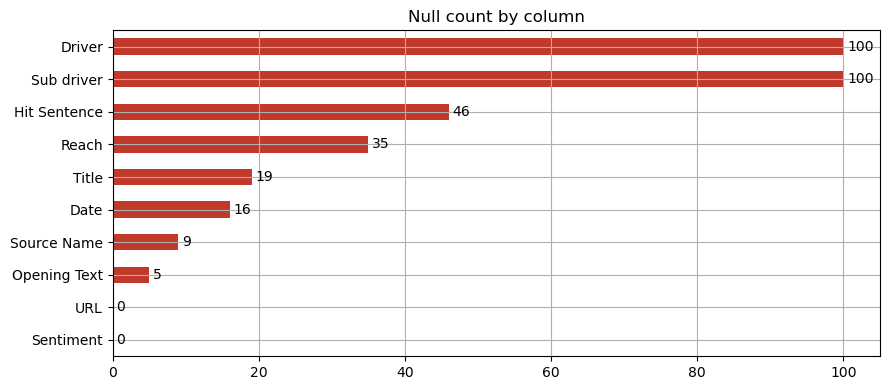

Driver          100
Sub driver      100
Hit Sentence     46
Reach            35
Title            19
Date             16
Source Name       9
Opening Text      5
URL               0
Sentiment         0
dtype: int64

In [4]:
miss = df.isna().sum().sort_values(ascending=False)
ax = miss.plot(kind='barh', color='#c0392b')
ax.set_title('Null count by column')
ax.invert_yaxis()
for i, v in enumerate(miss.values):
    ax.text(v+0.5, i, str(v), va='center')
plt.tight_layout(); plt.show()
miss

In [5]:
# How many rows have NO usable text at all (Title, Opening Text, Hit Sentence all null)?
text_cols = ['Title', 'Opening Text', 'Hit Sentence']
no_text = df[text_cols].isna().all(axis=1)
print('Rows with all three text fields empty:', int(no_text.sum()))
# Coverage of at least one text field
print('Rows with >=1 text field present:', int((~no_text).sum()))
df.loc[no_text, ['Date','Source Name','URL']]

Rows with all three text fields empty: 0
Rows with >=1 text field present: 100


,Date,Source Name,URL


**Implication:** No single text column is complete (`Title` 19 nulls, `Hit Sentence` 46 nulls),
but almost every row has *at least one* text field. The pipeline must build a **unified text blob**
= `Title` + `Opening Text` + `Hit Sentence` rather than relying on any one column.


## 4. Duplicate analysis (the important subtlety)

In [6]:
print('Exact full-row duplicates :', int(df.duplicated().sum()))
print('Duplicate URLs            :', int(df['URL'].duplicated().sum()))
print('Duplicate Titles          :', int(df['Title'].duplicated().sum()))
print('Dup on Title+Opening Text :', int(df.duplicated(subset=['Title','Opening Text']).sum()))

Exact full-row duplicates : 1
Duplicate URLs            : 15
Duplicate Titles          : 24
Dup on Title+Opening Text : 4


In [7]:
# Which URLs repeat the most?
df['URL'].value_counts().head(5)

URL
https://play.google.com/store/apps/details?id=com.iPruAMC&hl=en_IN                                                                                                                         15
https://www.reddit.com/r/mutualfunds/comments/1mseu7v                                                                                                                                       2
https://economictimes.indiatimes.com/mf/mf-news/all-the-risk-now-lies-with-investors-warns-icici-prudential-amcs-sankaran-naren/articleshow/125086832.cms                                   1
https://economictimes.indiatimes.com/mf/analysis/best-gilt-mutual-funds-to-invest-in-november-2025/articleshow/125531393.cms                                                                1
https://www.newspointapp.com/english/business/12-equity-mutual-funds-with-over-rs-1000-nav-deliver-over-15-cagr-since-inception-et/articleshow/145048209f0dd225f005284a4b8acb05ea7e08af     1
Name: count, dtype: int64

In [8]:
# CAUTION: the most-repeated URL is the Play Store app page — each row is a DISTINCT review.
app_url = df['URL'].value_counts().index[0]
print('Most repeated URL:', app_url, '\n')
cols = ['Source Name','Opening Text','Sentiment']
df.loc[df['URL'] == app_url, cols].head(6)

Most repeated URL: https://play.google.com/store/apps/details?id=com.iPruAMC&hl=en_IN 



,Source Name,Opening Text,Sentiment
5,NaN,yours is the most hopeless mutual fund app ever in terms of registration...i being a way long in...,Negative
6,Play Store,Easy to use good for self investment,Positive
17,NaN,"Good thing, they did listen and introduced 'manage SIP' link. Upgrading rating to 4 accordingly ...",neutral
21,Play Store,"On Android, during any lumpsum payment, the transaction is successful but fails to redirect to t...",Negative
26,Play Store,Absolutely love the new logo design.It's now very easy for someone like me who always forgets pa...,Positive
31,NaN,Every two weeks it fails to connect and forces to reinstall while same reports are shown in mult...,Negative


**Key finding — do NOT dedup naively on URL.**

The Play Store app URL (`play.google.com/.../com.iPruAMC`) appears ~15 times, but each row is a
**different user review** of the same app. Dropping by URL would destroy real, distinct signal
(app/UX complaints). True duplicates are syndicated articles re-posted across aggregators.

**Dedup strategy:** deduplicate on **normalized content** (lowercased, whitespace-collapsed
`Title + Opening Text + Hit Sentence`), not on URL alone. Optionally use near-duplicate matching
(e.g. fuzzy/TF-IDF cosine) to catch reworded syndication.


## 5. Sentiment field audit

In [9]:
print(df['Sentiment'].value_counts(dropna=False))
# Casing inconsistency: 'Positive' vs 'positive', 'Negative' vs 'negative'
norm = df['Sentiment'].astype(str).str.strip().str.lower()
print('\nAfter normalizing case:')
print(norm.value_counts(dropna=False))

Sentiment
neutral     52
positive    33
Negative    12
Positive     3
Name: count, dtype: int64

After normalizing case:
Sentiment
neutral     52
positive    36
negative    12
Name: count, dtype: int64


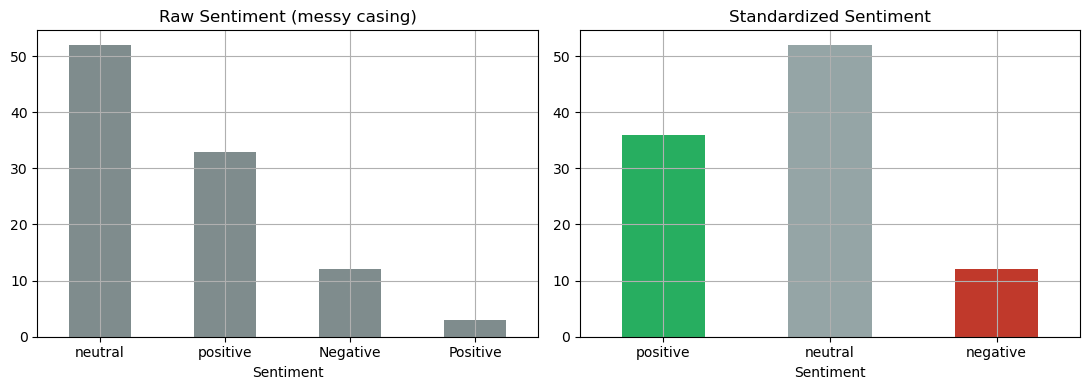

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df['Sentiment'].value_counts().plot(kind='bar', ax=ax[0], color='#7f8c8d')
ax[0].set_title('Raw Sentiment (messy casing)')
order = ['positive','neutral','negative']
colors = {'positive':'#27ae60','neutral':'#95a5a6','negative':'#c0392b'}
vc = norm.value_counts().reindex(order)
vc.plot(kind='bar', ax=ax[1], color=[colors[x] for x in order])
ax[1].set_title('Standardized Sentiment')
for a in ax: a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

**Finding:** `Sentiment` *is* pre-filled but inconsistent — `Positive`/`positive` and
`Negative` are separate buckets due to casing. Two decisions for the pipeline:

1. **Standardize** casing → {Positive, Neutral, Negative} (trivial, mandatory).
2. **Re-classify vs. trust:** the assignment explicitly asks us to *classify sentiment*. The
   provided labels are a useful **ground-truth / validation set**. Recommended approach: run our own
   model-based sentiment classifier on all records, then **report agreement** with the provided
   labels as a quality metric (and use provided labels to spot-check).


## 6. Driver / Sub-driver — the columns we must generate

In [11]:
print('Driver  non-null:', df['Driver'].notna().sum(), '/', len(df))
print('Sub driver non-null:', df['Sub driver'].notna().sum(), '/', len(df))
print('\n=> Both are 100% EMPTY. Classification into Driver + Sub-driver is the core task.')

Driver  non-null: 0 / 100
Sub driver non-null: 0 / 100

=> Both are 100% EMPTY. Classification into Driver + Sub-driver is the core task.


In [12]:
# The Classification Framework we must map every relevant record into:
framework = {
 'Brand Perception': ['Thought Leadership', 'Product Strategy', 'Brand Visibility & Marketing'],
 'User Experience': ['Product & Service Quality', 'Customer Support & Complaint Resolution',
                     'Digital & Omnichannel Experience'],
 'Responsible Business Practices': ['Regulatory Compliance & Ethical Governance',
                                    'Social Impact & Community (CSR)'],
}
for d, subs in framework.items():
    print(d)
    for s in subs:
        print('   -', s)

Brand Perception
   - Thought Leadership
   - Product Strategy
   - Brand Visibility & Marketing
User Experience
   - Product & Service Quality
   - Customer Support & Complaint Resolution
   - Digital & Omnichannel Experience
Responsible Business Practices
   - Regulatory Compliance & Ethical Governance
   - Social Impact & Community (CSR)


In [13]:
# Some Play Store / Mouthshut rows leak a category hint into the Title field.
hint_mask = df['Title'].isin(['Digital Experience','Customer Support','Product & Service Quality'])
print('Rows whose Title is actually a category hint:', int(hint_mask.sum()))
df.loc[hint_mask, ['Source Name','Title','Opening Text','Sentiment']].head()

Rows whose Title is actually a category hint: 7


,Source Name,Title,Opening Text,Sentiment
6,Play Store,Digital Experience,Easy to use good for self investment,Positive
21,Play Store,Digital Experience,"On Android, during any lumpsum payment, the transaction is successful but fails to redirect to t...",Negative
26,Play Store,Digital Experience,Absolutely love the new logo design.It's now very easy for someone like me who always forgets pa...,Positive
27,Mouthshut,Customer Support,"There is a definite downslide in their services and record keeping, , in one of our various sche...",Negative
59,Play Store,Digital Experience,"Worst update ever – keeps logging out automatically! 😡 After the latest update, this app has bec...",Negative


**Findings:**
- `Driver` and `Sub driver` are **completely empty** → the central deliverable is to populate them
  for every *relevant* record using the 3-driver / 8-sub-driver framework above.
- A handful of app-store rows carry a coarse hint (`Digital Experience`, `Customer Support`) in the
  `Title` field. These are weak labels we can use to sanity-check the classifier — not rely on.


## 7. Source analysis

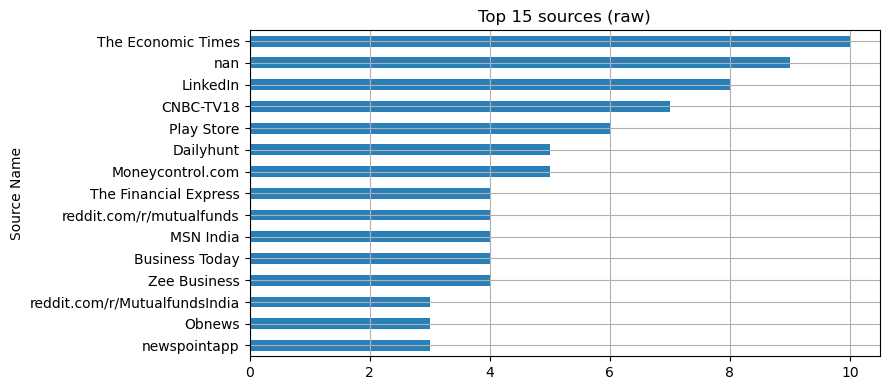

Source Name
The Economic Times               10
NaN                               9
LinkedIn                          8
CNBC-TV18                         7
Play Store                        6
Dailyhunt                         5
Moneycontrol.com                  5
The Financial Express             4
reddit.com/r/mutualfunds          4
MSN India                         4
Business Today                    4
Zee Business                      4
reddit.com/r/MutualfundsIndia     3
Obnews                            3
newspointapp                      3
Name: count, dtype: int64

In [14]:
top_src = df['Source Name'].value_counts(dropna=False).head(15)
ax = top_src.plot(kind='barh', color='#2980b9')
ax.set_title('Top 15 sources (raw)'); ax.invert_yaxis()
plt.tight_layout(); plt.show()
top_src

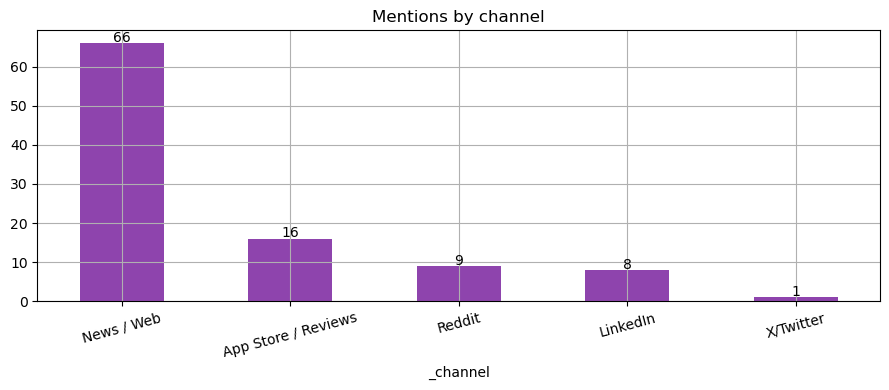

_channel
News / Web             66
App Store / Reviews    16
Reddit                  9
LinkedIn                8
X/Twitter               1
Name: count, dtype: int64

In [15]:
# Classify each source into a coarse channel for later analysis
def channel(row):
    s = str(row['Source Name']).lower()
    u = str(row['URL']).lower()
    if 'reddit' in s or 'reddit' in u: return 'Reddit'
    if 'linkedin' in s or 'linkedin' in u: return 'LinkedIn'
    if 'play.google' in u or 'play store' in s or 'mouthshut' in s: return 'App Store / Reviews'
    if 'x.com' in u or 'twitter' in u: return 'X/Twitter'
    return 'News / Web'
df['_channel'] = df.apply(channel, axis=1)
ch = df['_channel'].value_counts()
ax = ch.plot(kind='bar', color='#8e44ad')
ax.set_title('Mentions by channel'); ax.tick_params(axis='x', rotation=15)
for i,v in enumerate(ch.values): ax.text(i, v+0.3, str(v), ha='center')
plt.tight_layout(); plt.show()
ch

**Finding:** Mix of **News/Web** (ET, CNBC, Moneycontrol, aggregators), **social** (Reddit,
LinkedIn), and **first-party UX signal** (Play Store / Mouthshut reviews). Channel will be a useful
dashboard filter, and channel correlates with likely drivers (e.g. app reviews → Digital Experience).


## 8. Relevance assessment (irrelevant records to remove)

In [16]:
def blob(r):
    return ' '.join('' if pd.isna(r[c]) else str(r[c])
                    for c in ['Title','Opening Text','Hit Sentence','URL'])
df['_text'] = df.apply(blob, axis=1)
df['_text_lc'] = df['_text'].str.lower()

brand_terms = ['icici prudential', 'icici pru', 'ipruamc', 'ipru', 'icici amc']
df['_mentions_brand'] = df['_text_lc'].apply(lambda t: any(b in t for b in brand_terms))
print('Explicitly mention the brand:', int(df['_mentions_brand'].sum()))
print('Do NOT explicitly mention brand:', int((~df['_mentions_brand']).sum()))

Explicitly mention the brand: 78
Do NOT explicitly mention brand: 22


In [17]:
# Of the rows that don't mention the brand, which are app reviews (still relevant)
# vs generic listicles / clearly off-topic?
no_brand = df[~df['_mentions_brand']].copy()
no_brand['app_review'] = no_brand['_channel'].eq('App Store / Reviews')
print('Non-brand rows that are app reviews (RELEVANT):', int(no_brand['app_review'].sum()))
print('Non-brand rows that are NOT app reviews (suspect):', int((~no_brand['app_review']).sum()))
no_brand.loc[~no_brand['app_review'], ['Source Name','Title']].head(20)

Non-brand rows that are app reviews (RELEVANT): 1
Non-brand rows that are NOT app reviews (suspect): 21


,Source Name,Title
8,Equitymaster.com,3 Mutual Funds That are Down Less Than 5% in the Market Downturn
10,Shiksha.com,"Best MBA Colleges in Kalyan: Courses, Fees, Admission, Entrance Exams, Placements"
15,News18,Multi-Asset Funds Or Aggressive Hybrid Funds: Who Outperformed Over 10 Years?
22,Dailyhunt,Top High-Return Small Cap Mutual Funds in India
29,The Financial Express,Best multi cap mutual funds to invest in 2025
30,The Economic Times,35 equity mutual funds complete over 25 years in 2025. How much returns did they offer?
34,Dailyhunt,Best Mutual Funds to Invest in December 2025
44,Dailyhunt,Best ETFs to Invest in India in 2025
47,Goodreturns,"Best Mutual Funds: ICICI, HDFC, SBI Nippon Among Consistent Performers In Mid, Small, Large Cap ..."
48,The Financial Express,"Best index funds: Smallcap, midcap and Nifty 50 compared across 3, 5 and 10-year return charts"


In [18]:
# Obvious off-topic example caught by EDA
df.loc[df['_text_lc'].str.contains('mba colleges', na=False), ['Source Name','Title']]

,Source Name,Title
10,Shiksha.com,"Best MBA Colleges in Kalyan: Courses, Fees, Admission, Entrance Exams, Placements"


**Findings — relevance is a real problem, but nuanced:**
- ~37 rows don't mention "ICICI Prudential" explicitly. **Not all are irrelevant:** app-store
  reviews of the iPruAMC app are highly relevant UX signal even without naming the brand in text.
- True noise exists: e.g. *"Best MBA Colleges in Kalyan"* (Shiksha.com) — clearly off-topic.
- Many *"Best Mutual Funds to Invest…"* listicles mention ICICI Pru among many funds — **borderline**;
  relevant only if ICICI Pru is a meaningful subject, not a passing list item.

**Relevance strategy:** a two-tier filter — (1) keep if brand is explicitly mentioned OR it is a
first-party app/review channel; (2) for borderline listicles, use an LLM relevance check
("is ICICI Prudential a primary subject?"). Drop hard off-topic rows.


## 9. Text-length analysis (what the classifier will actually see)

       _text_len  _word_count
count      100.0        100.0
mean       486.2         81.8
std       1095.1        186.5
min         53.0          9.0
25%        228.5         38.0
50%        339.5         54.5
75%        381.2         65.2
max       7996.0       1361.0


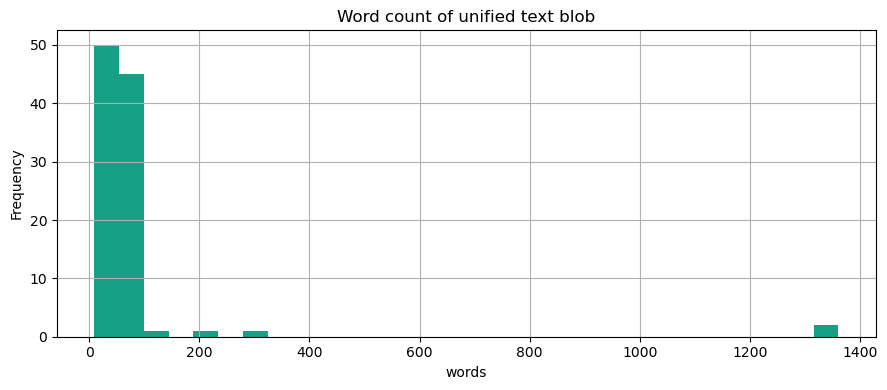

In [19]:
df['_text_clean'] = (df['_text']
    .str.replace(r'https?://\S+', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip())
df['_text_len'] = df['_text_clean'].str.len()
df['_word_count'] = df['_text_clean'].str.split().apply(len)
print(df[['_text_len','_word_count']].describe().round(1))
ax = df['_word_count'].plot(kind='hist', bins=30, color='#16a085')
ax.set_title('Word count of unified text blob'); ax.set_xlabel('words')
plt.tight_layout(); plt.show()

In [20]:
# Shortest texts - are they classifiable?
df.nsmallest(8, '_word_count')[['Source Name','_word_count','_text_clean']]

,Source Name,_word_count,_text_clean
6,Play Store,9,Digital Experience Easy to use good for self investment
39,NaN,11,app's is very good but you tube channel not in Hindi.
95,NaN,14,many features missing.like my transaction and live sip and much more. not cancelled otm.
87,reddit.com/r/MutualfundsIndia,22,"Icici prudential multi asset fund This alone is sufficient to cover gold , bond ,.silver , stock..."
52,Dailyhunt,23,"Best Performing Low-Risk Mutual Funds for 2025 Overview:Diversified allocation across equity, de..."
46,The Hindu Business Line,24,ICICI Pru AMC relieves Sankaran Naren from managing Dynamic Asset Allocation FoF The fund manage...
22,Dailyhunt,28,Top High-Return Small Cap Mutual Funds in India Quant Small Cap Fund: Achieved a 5-year CAGR of ...
34,Dailyhunt,28,Best Mutual Funds to Invest in December 2025 Overview:Top-performing mutual funds in December 20...


**Finding:** Texts are short snippets (titles + opening + a hit-sentence fragment), not full
articles. A few rows have very little text. This favours an **LLM/zero-shot classifier** over a
trained model (no labelled training data, short context), and means some ultra-short rows may need
to fall back to driver-only (no confident sub-driver).


## 10. Reach (impact weighting)

count          65.0
mean      9487623.0
std      10446937.0
min         41256.0
25%        801433.0
50%       7020100.0
75%      12772308.0
max      62646070.0
Name: Reach, dtype: float64
Reach nulls: 35


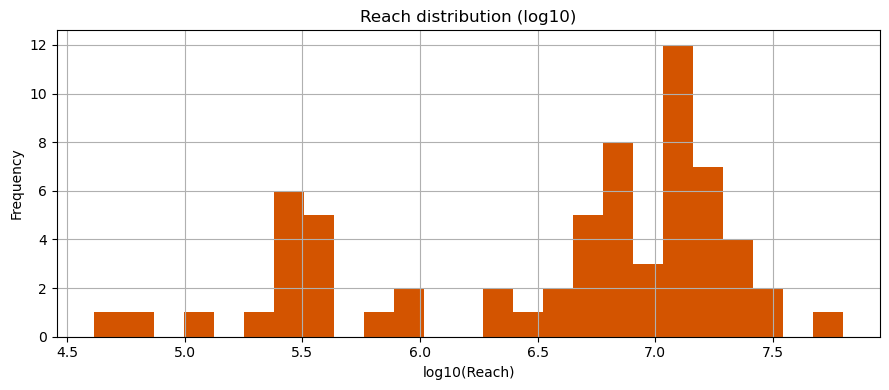

In [21]:
print(df['Reach'].describe().round(0))
print('Reach nulls:', int(df['Reach'].isna().sum()))
ax = np.log10(df['Reach'].dropna()+1).plot(kind='hist', bins=25, color='#d35400')
ax.set_title('Reach distribution (log10)'); ax.set_xlabel('log10(Reach)')
plt.tight_layout(); plt.show()

**Finding:** `Reach` is right-skewed (few very-high-reach mainstream articles, many small ones)
and 35% null. Useful as an **impact weight** in the dashboard (e.g. "negative mentions weighted by
reach"), but must handle nulls (treat as unknown / median-impute for ranking only).


## 11. Temporal coverage

Date range: 2025-07-01 00:00:00 -> 2026-03-12 00:00:00 | nulls: 16


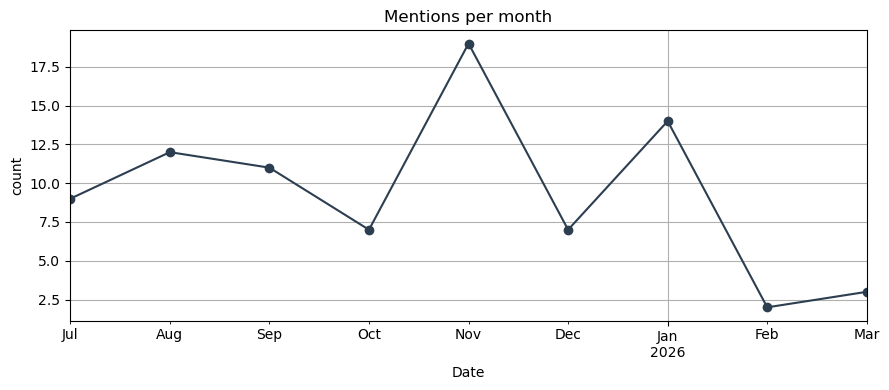

In [22]:
dd = df.dropna(subset=['Date']).copy()
print('Date range:', df['Date'].min(), '->', df['Date'].max(), '| nulls:', int(df['Date'].isna().sum()))
ax = dd.set_index('Date').resample('ME').size().plot(marker='o', color='#2c3e50')
ax.set_title('Mentions per month'); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

## 12. Summary of findings → pipeline implications

| # | Finding | Implication for the pipeline |
|---|---------|------------------------------|
| 1 | `Driver` & `Sub driver` are **100% empty** | Core task = classify every relevant row into 3 drivers / 8 sub-drivers |
| 2 | `Sentiment` pre-filled but **messy casing** | Standardize to {Positive,Neutral,Negative}; re-classify + report agreement as QA |
| 3 | Play Store URL repeats ~15× but rows are **distinct reviews** | Dedup on **normalized content**, never on URL alone |
| 4 | No text column is complete; ~most rows have ≥1 | Build **unified text blob** = Title+Opening+HitSentence |
| 5 | ~37 rows don't name the brand; some relevant (app), some noise (MBA colleges) | **Two-tier relevance filter** (brand/channel rule + LLM borderline check) |
| 6 | Sources span News, Reddit, LinkedIn, App stores | Derive a **channel** field; strong prior for some drivers |
| 7 | Texts are **short snippets** | Favour **LLM zero-shot** classification; sub-driver may be low-confidence on tiny rows |
| 8 | `Reach` skewed + 35% null | Use as **impact weight** with null handling |
| 9 | Dates 16 nulls, Jul'25–Mar'26 | Temporal trend possible on the dated subset |

**Recommended pipeline order:** Load → Standardize (casing, whitespace, dates, build text blob) →
Dedup on content → Relevance filter → LLM classification (Driver + Sub-driver + Sentiment with
confidence) → Validate (agreement vs provided sentiment, hint rows) → Export cleaned & classified
dataset → Dashboard.
